# 网约车优惠券 A/B 测试分析

## tl;dr

- 实验组日均 GMV 比对照组低 **6,111（-1.26%）**。按日期配对后差异显著：配对 t 检验 **p=0.0002**，Wilcoxon **p=0.0018**。
- 若错误忽略日期配对，Welch 独立样本检验得到 **p=0.9387**。方法选择改变了结论，因为配对分析消除了两组共同的日期波动。
- 实验组优惠券成本增加约 **0.77%**，绝对 ROI 下降约 **2.41%**；补贴没有转化为 GMV 增长。
- 完成率提高约 **0.20 个百分点**、取消率降低约 **0.21 个百分点**，但不足以抵消 GMV 和客单价下降。
- GMV负向效果主要集中在实验后半程，且两组券额均随时间下降，因此处理强度并非恒定，推广前应控制券额路径并进行二次验证。


## Context & Methods

### Decision

判断提高优惠券力度是否值得推广，并区分统计显著性与业务价值。

### Key Assumptions

- 数据为 29 天、对照组与实验组同日期对齐的汇总结果。
- 日期对齐与同步波动支持日期级配对分析，但缺少用户级分流日志，不能完全验证随机化机制。
- 原始数据未提供实验方案、灰度记录与样本量设计；相关流程在报告中标记为“方案补充”。
- ROI 仅表示 GMV 与优惠券成本的关系，不代表利润 ROI。

### Methods

- 描述性指标与补贴经济性
- 日期级配对 t 检验
- Wilcoxon 符号秩检验
- Bootstrap 置信区间与分阶段稳健性检查
- Holm 多重检验校正
- 功效、样本量和 MDE 敏感性分析


## Data

### 1. 运行可复现分析

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if PROJECT.name != "didi_ab_test_project":
    PROJECT = Path.cwd().resolve() / "didi_ab_test_project"
sys.path.insert(0, str(PROJECT / "src"))

import run_analysis
run_analysis.main()
TABLE_DIR = PROJECT / "outputs" / "tables"
CHART_DIR = PROJECT / "outputs" / "charts"


D:\anaconda\lib\site-packages\scipy\stats\_morestats.py:3255: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


{
  "validation": {
    "rows": 58,
    "columns": 12,
    "missing_cells": 0,
    "duplicate_rows": 0,
    "unique_dates": 29,
    "group_counts": {
      "control": 29,
      "experiment": 29
    },
    "complete_date_pairs": true,
    "date_start": "2019-01-01",
    "date_end": "2019-01-29",
    "group_date_summary": {
      "min": {
        "control": "2019-01-01",
        "experiment": "2019-01-01"
      },
      "max": {
        "control": "2019-01-29",
        "experiment": "2019-01-29"
      },
      "nunique": {
        "control": "29",
        "experiment": "29"
      }
    }
  },
  "gmv": {
    "metric": "gmv",
    "metric_cn": "GMV",
    "n_pairs": 29,
    "control_mean": 485123.5972413793,
    "experiment_mean": 479012.4313793103,
    "mean_diff": -6111.165862068965,
    "relative_diff": -0.012597131734716004,
    "ci_low": -9058.289744602449,
    "ci_high": -3164.0419795354806,
    "t_stat": -4.247583846321442,
    "paired_t_p": 0.00021564303983362577,
    "wilcoxon_p": 0

### 2. 数据结构与质量

In [2]:
data = run_analysis.load_and_prepare()
validation = run_analysis.validate_structure(data)
validation

{'rows': 58,
 'columns': 12,
 'missing_cells': 0,
 'duplicate_rows': 0,
 'unique_dates': 29,
 'group_counts': {'control': 29, 'experiment': 29},
 'complete_date_pairs': True,
 'date_start': '2019-01-01',
 'date_end': '2019-01-29',
 'group_date_summary': {'min': {'control': '2019-01-01',
   'experiment': '2019-01-01'},
  'max': {'control': '2019-01-29', 'experiment': '2019-01-29'},
  'nunique': {'control': '29', 'experiment': '29'}}}

数据包含 58 行、29 个日期，两组各 29 行；无缺失和重复，所有日期均形成完整配对。

## Results

### 3. 两组总体表现

In [3]:
summary = pd.read_csv(TABLE_DIR / "group_summary.csv", index_col=0)
display(summary.round(4))

,days,requests_total,trips_total,gmv_total,coupon_cost_total,completion_rate_weighted,cancel_rate_weighted,aov_weighted,roi_aggregate,coupon_per_trip_mean
group,,,,,,,,,,
control,29,59448,47411,14068584.32,37309.2142,0.7975,0.0724,296.7367,377.0807,0.8444
experiment,29,59233,47335,13891360.51,37595.9942,0.7991,0.0707,293.4691,369.4904,0.8520


### 4. 每日趋势与处理强度

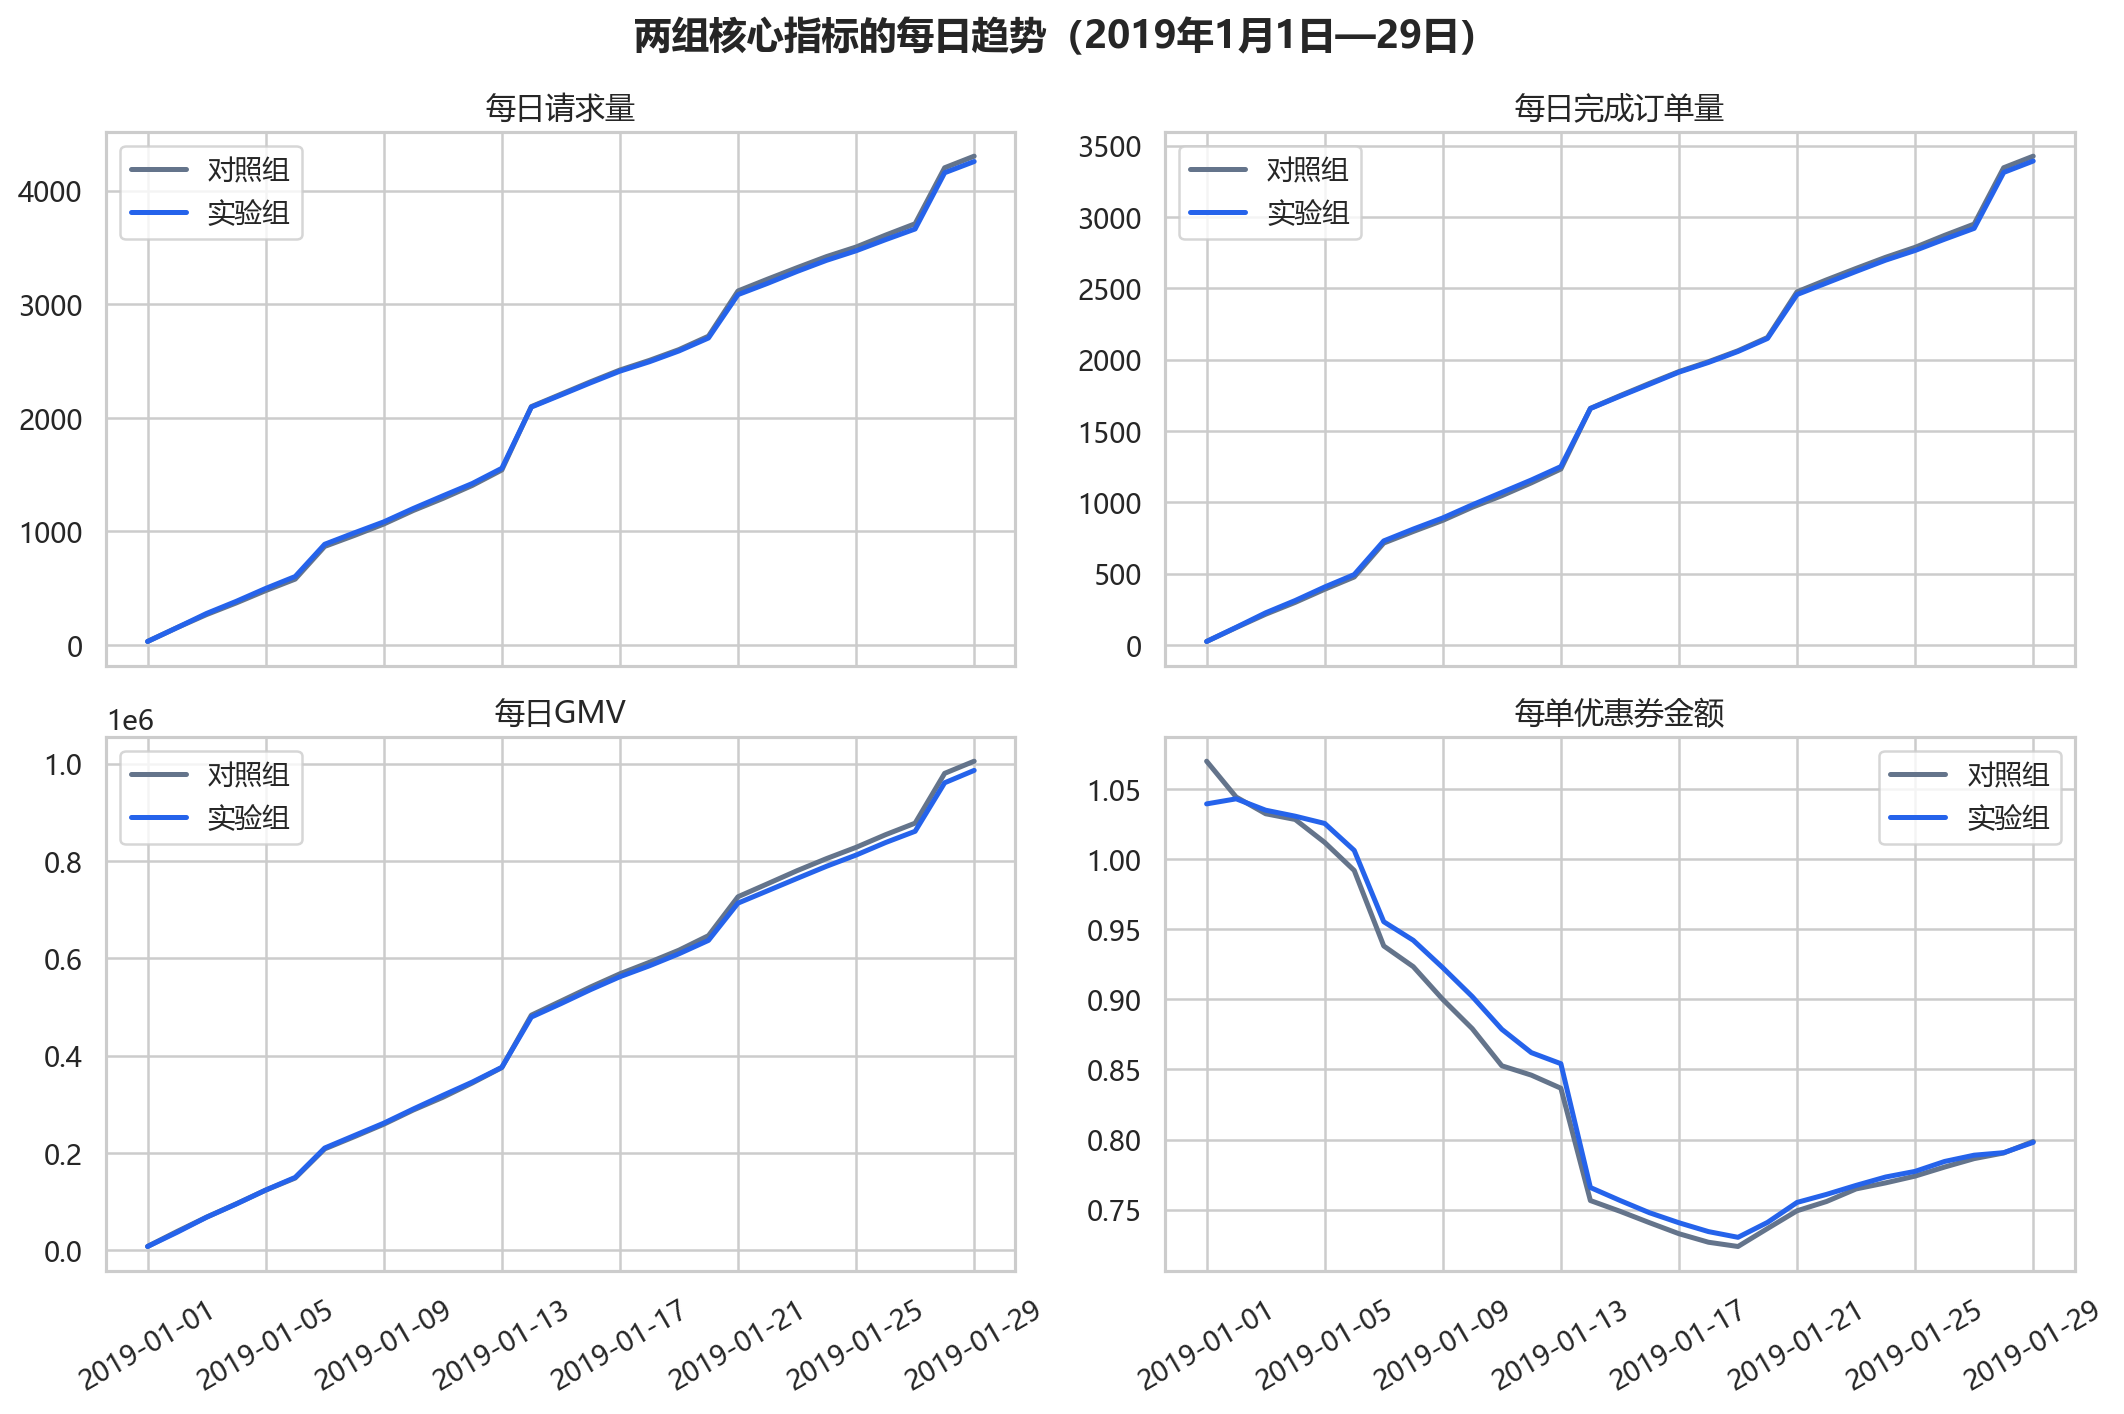

In [4]:
display(Image(filename=str(CHART_DIR / "01_daily_trends.png")))

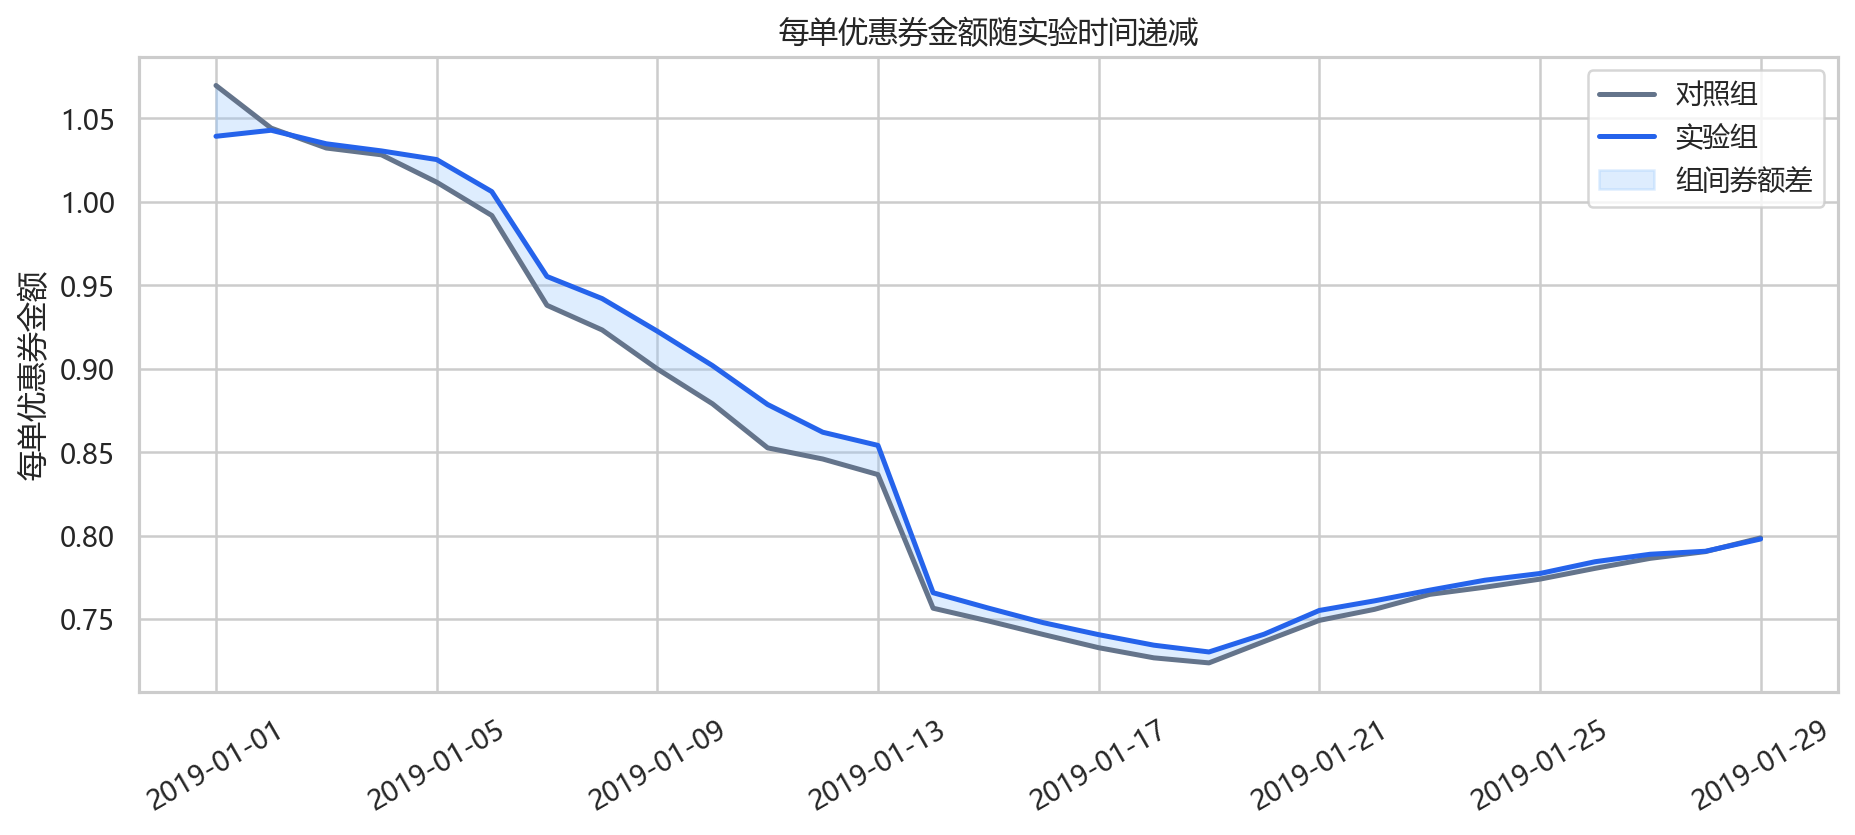

In [5]:
display(Image(filename=str(CHART_DIR / "06_coupon_intensity_trend.png")))

两组请求量、订单量和 GMV 随日期同步波动，配对结构明显。每单券额并非固定干预，而是随时间持续下降。

### 5. 配对检验与效应量

In [6]:
tests = pd.read_csv(TABLE_DIR / "paired_test_results.csv")
cols = ["metric_cn", "control_mean", "experiment_mean", "relative_diff",
        "mean_diff", "ci_low", "ci_high", "paired_t_p", "wilcoxon_p",
        "paired_t_p_holm", "cohen_dz"]
display(tests[cols].round(6))

,metric_cn,control_mean,experiment_mean,relative_diff,mean_diff,ci_low,ci_high,paired_t_p,wilcoxon_p,paired_t_p_holm,cohen_dz
0,请求量,2049.931034,2042.517241,-0.003617,-7.413793,-16.653472,1.825886,0.111440,0.215748,0.222879,-0.305211
1,完成订单量,1634.862069,1632.241379,-0.001603,-2.620690,-9.493447,4.252068,0.441304,0.356028,0.441304,-0.145045
2,GMV,485123.597241,479012.431379,-0.012597,-6111.165862,-9058.289745,-3164.041980,0.000216,0.001816,0.001078,-0.788757
3,优惠券成本,1286.524629,1296.413593,0.007687,9.888964,2.524704,17.253225,0.010306,0.009216,0.030918,0.510786
4,绝对ROI,360.367323,351.680906,-0.024104,-8.686417,-10.413001,-6.959833,0.000000,0.000000,0.000000,-1.913684
5,完成率,0.801879,0.803839,0.002445,0.001960,0.000869,0.003052,0.000987,0.000294,0.003950,0.683114
6,取消率,0.065048,0.062916,-0.032780,-0.002132,-0.002678,-0.001587,0.000000,0.000004,0.000000,-1.486502
7,客单价,300.239629,295.335818,-0.016333,-4.903811,-6.574687,-3.232935,0.000002,0.000000,0.000011,-1.116367


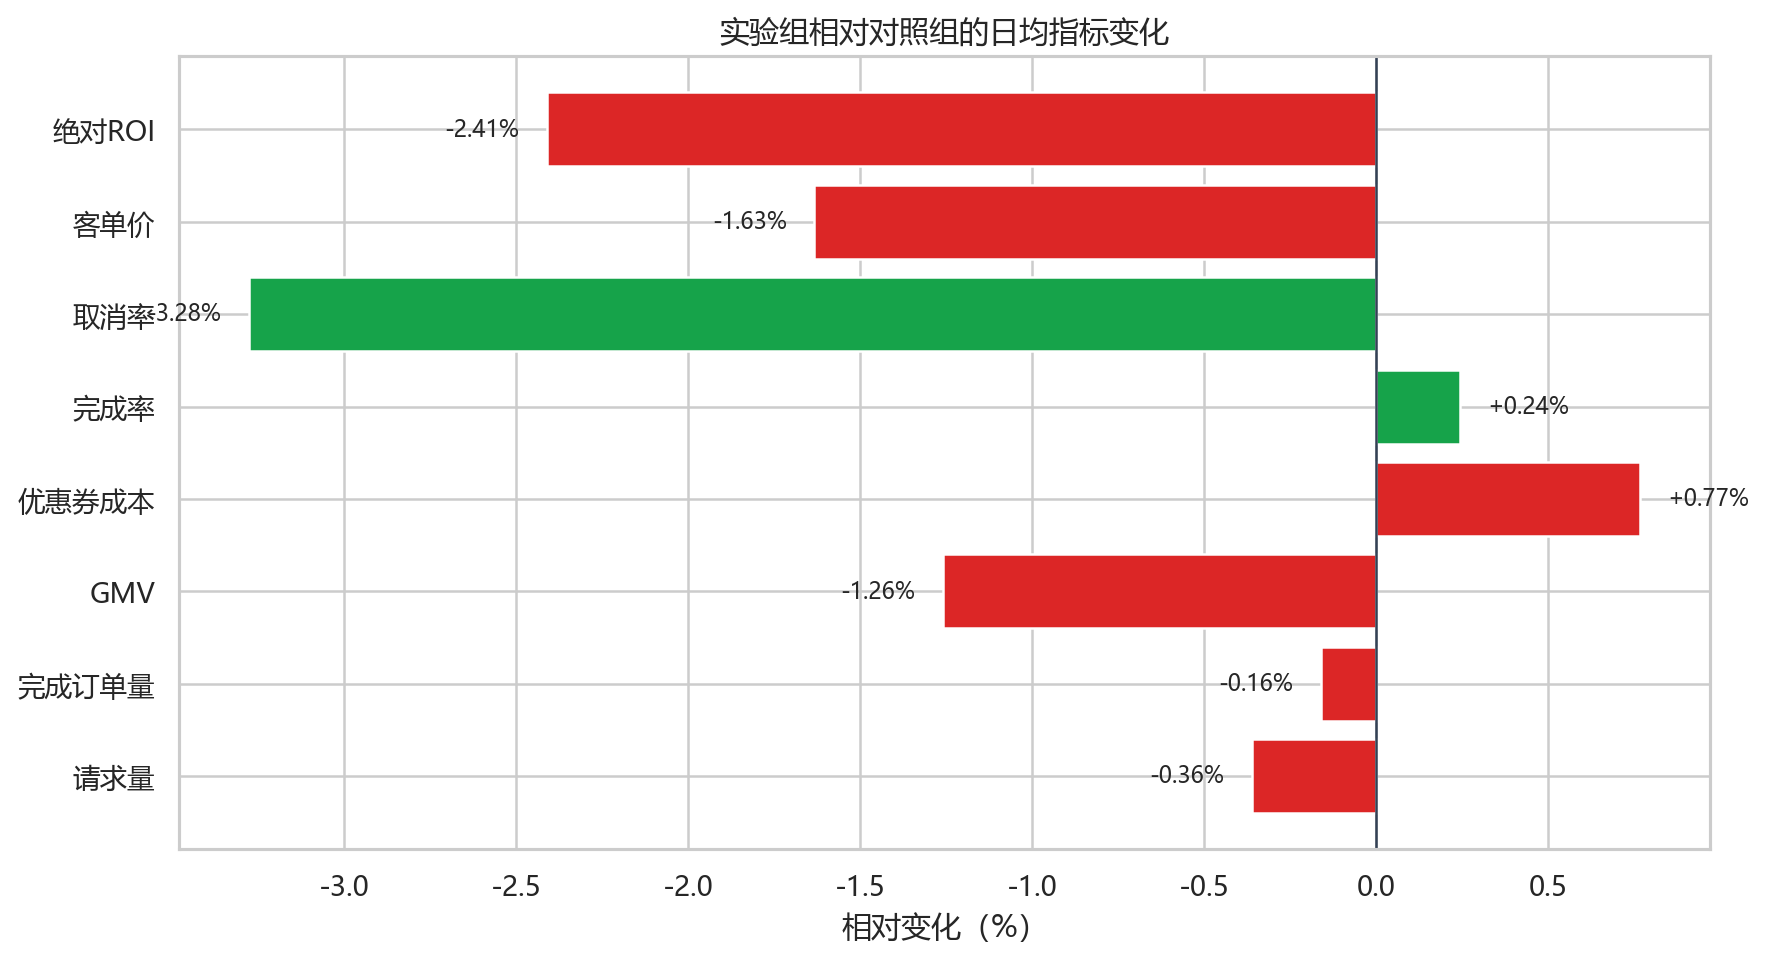

In [7]:
display(Image(filename=str(CHART_DIR / "03_metric_lifts.png")))

### 6. 独立样本与配对检验的结论反转

,method,t_stat,p_value,conclusion_alpha_005
0,Welch independent-samples t-test,-0.077286,0.938672,not significant
1,Paired t-test by date,-4.247584,0.000216,significant


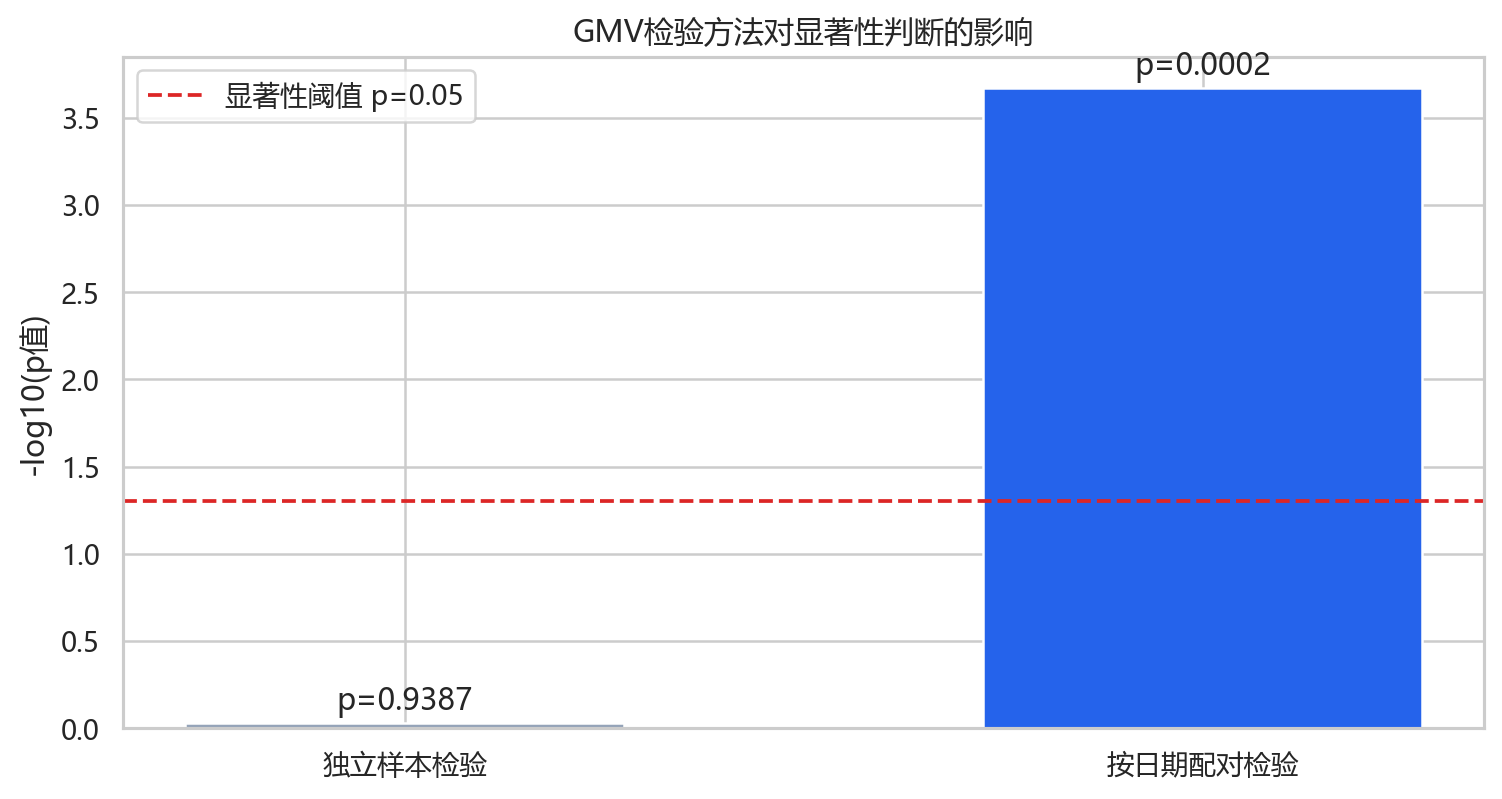

In [8]:
method_compare = pd.read_csv(TABLE_DIR / "gmv_method_comparison.csv")
display(method_compare.round(6))
display(Image(filename=str(CHART_DIR / "04_method_reversal.png")))

忽略日期配对时，跨日期波动掩盖了组间差异；配对检验利用同一天的组间差值，显著降低噪声。

### 7. GMV差值与稳健性

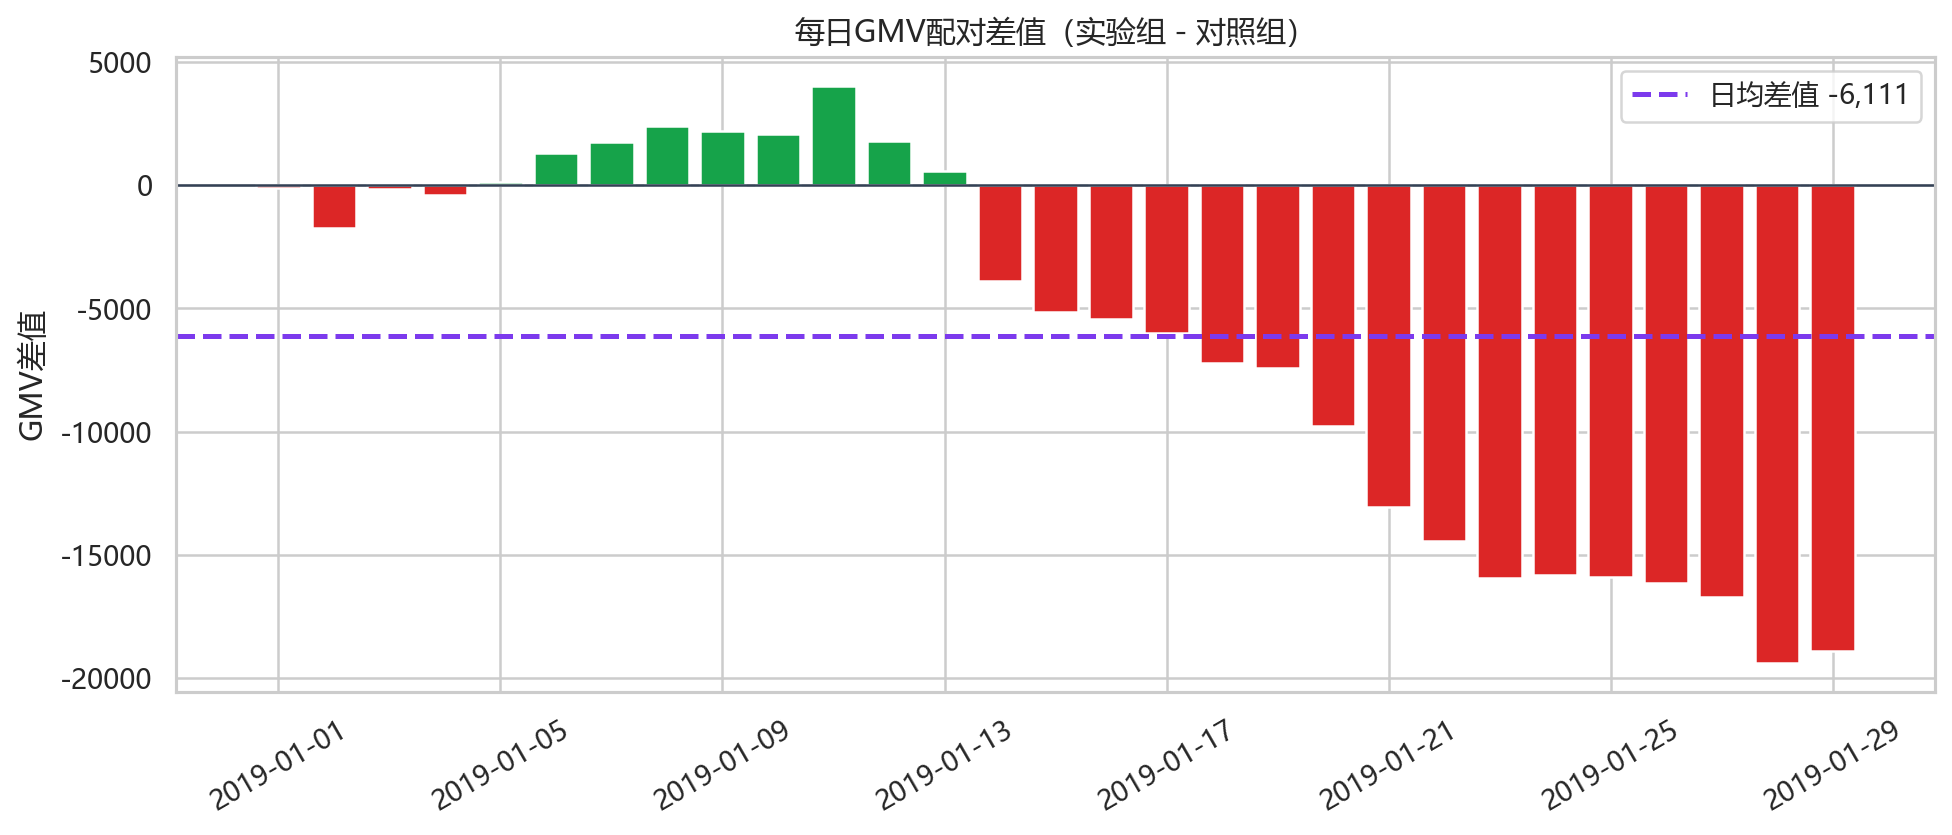

,check,n,mean_diff,ci_low,ci_high,p_value
0,bootstrap_20000,29,-6111.165862,-8909.034784,-3394.164655,NaN
1,exclude_abs_z_ge_2.5,29,-6111.165862,NaN,NaN,0.000216
2,first_half,14,723.227857,NaN,NaN,0.194187
3,second_half,15,-12489.933333,NaN,NaN,0.000000


In [9]:
display(Image(filename=str(CHART_DIR / "02_gmv_paired_difference.png")))
robustness = pd.read_csv(TABLE_DIR / "gmv_robustness_checks.csv")
display(robustness.round(6))

Bootstrap区间仍完全低于0；但前半程与后半程效果差异明显，提示策略效果随时间或券额路径变化。

### 8. 补贴经济性

In [10]:
economics = pd.read_csv(TABLE_DIR / "economics_summary.csv")
display(economics.round(4))

,delta_gmv,delta_coupon_cost,incremental_roi_gmv_per_coupon,net_incremental_value_gmv_minus_coupon
0,-177223.81,286.78,-617.9784,-177510.59


实验期内，实验组总GMV比对照组低约177,224，而优惠券成本高约287。增量ROI分母很小且收益为负，因此不应把该比值作为稳定的外推参数；决策重点是“额外补贴没有形成正向GMV增量”。

### 9. 功效与MDE

,n_pairs,observed_cohen_dz_abs,posthoc_power,pairs_needed_80_power,mde_cohen_dz_80_power,mde_gmv_absolute,mde_gmv_relative,alpha,target_power
0,29,0.788757,0.983738,15.0,0.538959,4175.769471,0.008608,0.05,0.8


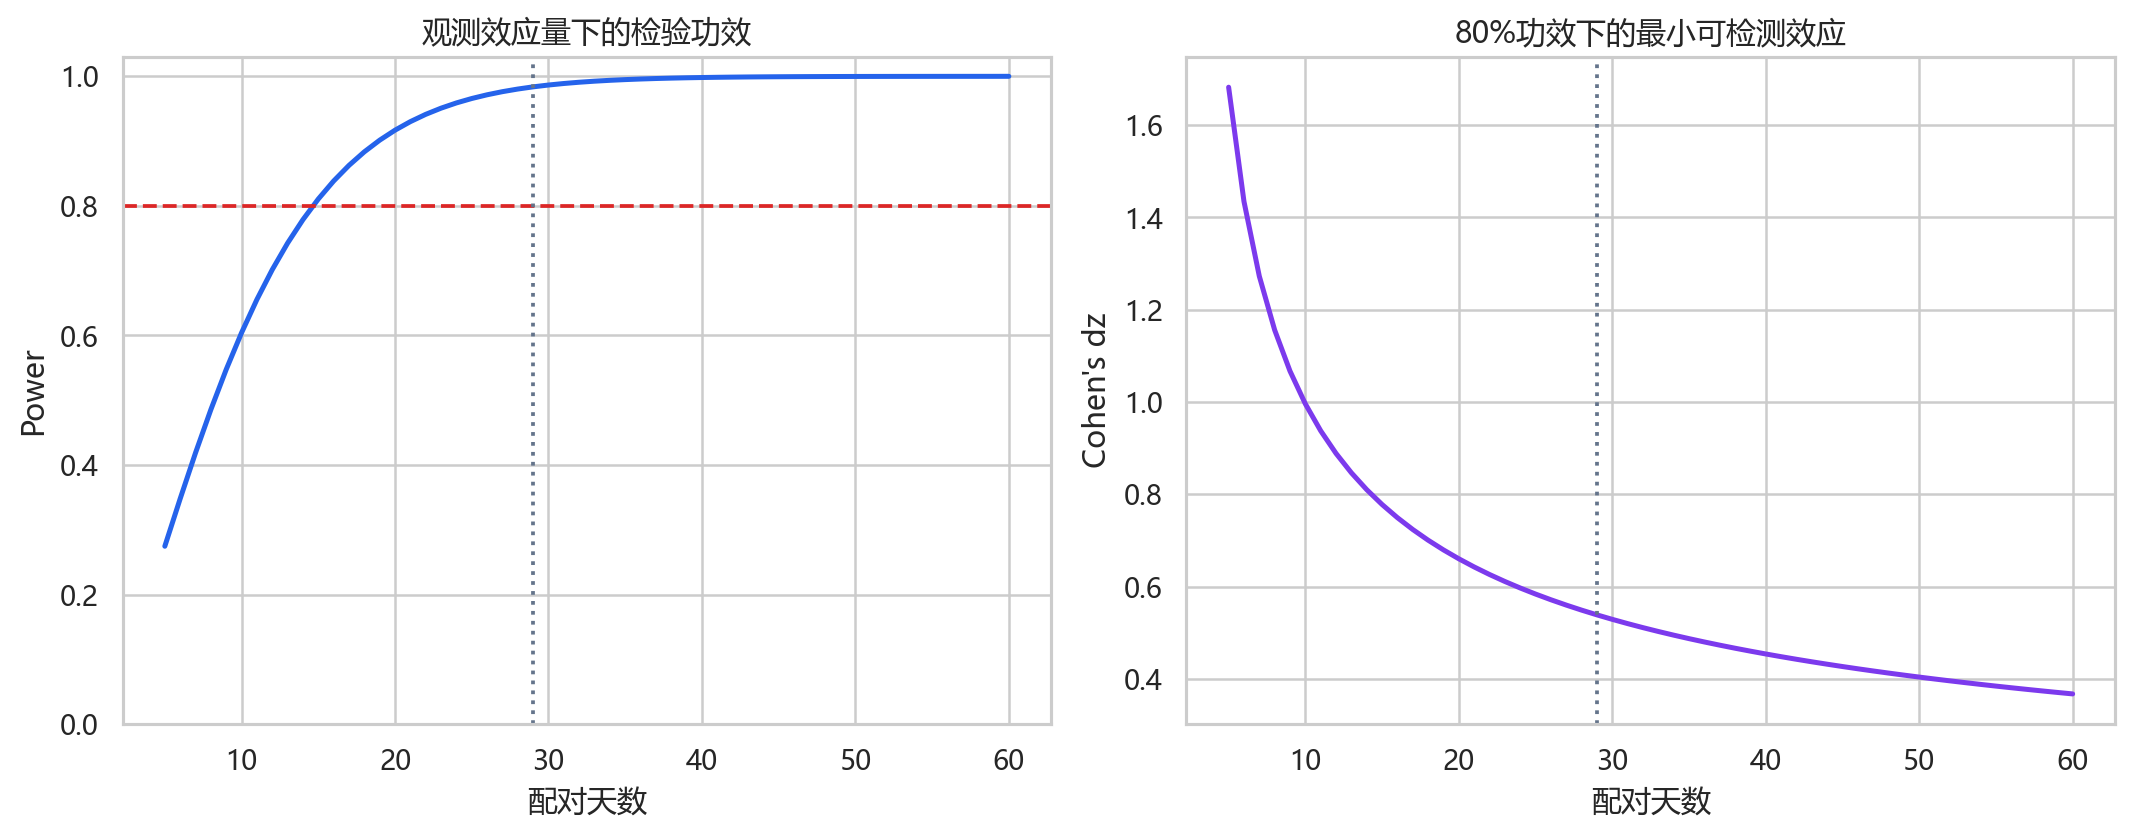

In [11]:
power = pd.read_csv(TABLE_DIR / "power_analysis.csv")
display(power.round(6))
display(Image(filename=str(CHART_DIR / "05_power_and_mde.png")))

当前29对样本下，80%功效对应的GMV MDE约为日均0.86%。基于已观测效应量计算的事后功效约98.4%，只作为敏感性描述，不作为独立证据。

## Takeaways

1. **不建议直接推广当前优惠券路径。** 实验组GMV和客单价显著下降，优惠券成本反而上升。
2. **配对检验是本项目的关键方法选择。** 独立样本检验会被共同日期波动掩盖，错误得出“没有差异”。
3. **体验护栏有所改善，但不能单独支持推广。** 完成率小幅提高、取消率下降，需要结合收益指标综合判断。
4. **建议进行第二轮受控实验。** 固定或分层控制券额，预先定义GMV或增量价值为主要指标，并保留完成率与取消率护栏。
5. **结论需保留边界。** 日期级汇总数据无法验证用户级随机化、SRM、重复曝光和长期效果。
